# Training on SQuAD

## Setup

In [1]:
# PRIVATE CELL
username = 'MarcelloCeresini'
repository = 'QuestionAnswering'

In [2]:
# COLAB ONLY CELLS
try:
    import google.colab
    IN_COLAB = True
    !pip3 install transformers
    !nvidia-smi             # Check which GPU has been chosen for us
    !rm -rf logs
    #from google.colab import drive
    #drive.mount('/content/drive')
    #%cd /content/drive/MyDrive/GitHub/
    !git clone https://github.com/{username}/{repository}.git
    %cd {repository}/src
    %ls
except:
    IN_COLAB = False

### Imports

In [3]:
# %load_ext tensorboard
import datetime

import os
from tqdm import tqdm
import random

from typing import List, Dict, Tuple

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision

import gc

import wandb
from wandb.keras import WandbCallback

%matplotlib inline


In [4]:
from config import Config
config = Config()
import utils

# Fix random seed for reproducibility
np.random.seed(config.RANDOM_SEED)
random.seed(config.RANDOM_SEED)
tf.random.set_seed(config.RANDOM_SEED)

### TPU check

The training could be made faster if we use the cloud GPUs offered by Google on Google Colab. Since TPUs require manual intialization and other oddities, we check multiple times throughout the notebook what kind of hardware we are running the code on.

In [5]:
using_TPU = False

if using_TPU:
    try: 
        resolver = tf.distribute.cluster_resolver.TPUClusterResolver(tpu='')
        tf.config.experimental_connect_to_cluster(resolver)
        # This is the TPU initialization code that has to be at the beginning.
        tf.tpu.experimental.initialize_tpu_system(resolver)
        print("All devices: ", tf.config.list_logical_devices('TPU'))
        strategy = tf.distribute.TPUStrategy(resolver)
    except:
        print("TPUs are not available, set flag 'using_TPU' to False.")
else:
    physical_devices = tf.config.list_physical_devices('GPU')
    print("Num GPUs Available: ", len(physical_devices))
    try:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
    except:
        # Invalid device or cannot modify virtual devices once initialized.
        pass
    os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
    mixed_precision.set_global_policy('mixed_float16')
    


Num GPUs Available:  1
INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 2060, compute capability 7.5


2022-02-24 08:56:19.477178: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-02-24 08:56:19.504398: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-02-24 08:56:19.504972: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-02-24 08:56:19.505972: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


## Dataset loading

We use some utility functions to load the training set and the validation set. The validation set was created on the `data_analysis.ipynb` notebook and it's just a fraction of the training set. 

In [6]:
TRAINING_FILE = os.path.join(config.ROOT_PATH, 'data', 'training_set.json')
VALIDATION_FILE = os.path.join(config.ROOT_PATH, 'data', 'validation_set.json')
train_dataset = utils.read_question_set(TRAINING_FILE)
val_dataset = utils.read_question_set(VALIDATION_FILE)

Note that since we did not remove the instances of the validation set from the training set json file for integrity, we must be careful and do it now before we train the model on it, otherwise the model would be seeing validation data inside its training data and be irreversibly biased. 

In [7]:
print("BEFORE:")
print("Instances in training split: ", len(train_dataset['data']))
print("Instances in validation split: ", len(val_dataset['data']))
print("======")

for val_el in val_dataset['data']:
    # We remove the matching elements
    train_dataset['data'].remove(val_el)

print("AFTER:")
print("Instances in training split: ", len(train_dataset['data']))
print("Instances in validation split: ", len(val_dataset['data']))

BEFORE:
Instances in training split:  442
Instances in validation split:  111
AFTER:
Instances in training split:  331
Instances in validation split:  111


In [8]:
# We also create small training and validation sets to test the model while building it, just to speed things up.
small_train_dataset = {'data': random.sample(train_dataset["data"], config.SMALL_TRAIN_LEN)}
small_val_dataset = {'data': random.sample(val_dataset["data"], config.SMALL_VAL_LEN)}

### Dataset choice

We have implemented many different methods of loading the dataset in memory depending on the needs of the user:
- `utils.create_full_dataset` uses `tf.data.Dataset.from_tensor_slices`. This method is the most stable way to create a high level Dataset object in Tensorflow and the only one that can be used by TPUs, but it's also quite memory-heavy since the whole dataset has to be preprocessed and this uses a lot of RAM.
- `utils.create_dataset_from_generator` uses `tf.data.Dataset.from_generator`. This method generates data on-the-fly whenever it's requested, because it uses an underlying Python generator to create data. Therefore, it has minimal impact on RAM, but it's slow at producing the data requested by the model, while "being fast at generating data" is the most important requirements of using TPUs.

By setting flags, we can decide what kind of loading strategy to use for training. The default flags use `utils.create_full_dataset` and disable the NER extension.

In [9]:
# SETUP FOR DATASET CREATION
# Notes:
# - When using TPUs, "create_and_save", "load" and "generator" are not used
# - Only one of "create_and_save", "load" or "generator" should be True

full_dataset = True # choose between full and small dataset
for_training = True         # True: returns a (feature, labels) dataset used in the fit method of the model
                            # False: returns a (feature, id) dataset used during inference

NER_attention = True       # returns another key inside the features

create_and_save = False     # fully create the dataset in RAM, and then save it on disk
load = True                # load a previously created dataset from disk
generator = False           # if not enough RAM, create a dataset through a generator

In [10]:
if full_dataset:
    TRAIN_DATASET = train_dataset
    VAL_DATASET = val_dataset
else:
    TRAIN_DATASET = small_train_dataset
    VAL_DATASET = small_val_dataset

if not using_TPU: # if using a TPU, simply create the dataset and store it in RAM
    # if you need to save or load a model, choose the right path according to the previous 2 flags
    if create_and_save or load:
        if for_training:
            if NER_attention:
                PATH_TRAIN = config.SAVE_PATH_TRAIN_DS_TRAINING_NER
                PATH_VAL = config.SAVE_PATH_VAL_DS_TRAINING_NER
            else:
                PATH_TRAIN = config.SAVE_PATH_TRAIN_DS_TRAINING
                PATH_VAL = config.SAVE_PATH_VAL_DS_TRAINING
        else:
            if NER_attention:
                PATH_TRAIN = config.SAVE_PATH_TRAIN_DS_INFERENCE_NER
                PATH_VAL = config.SAVE_PATH_VAL_DS_INFERENCE_NER
            else:
                PATH_TRAIN = config.SAVE_PATH_TRAIN_DS_INFERENCE
                PATH_VAL = config.SAVE_PATH_VAL_DS_INFERENCE

        print("Path training dataset: ", PATH_TRAIN)
        print("Path validation dataset: ", PATH_VAL)

    # dataset creation
    # for small dataset, just create it and store it in RAM, it's fast
    if create_and_save or not full_dataset: # for full dataset, you can either create it and save it on disk
        train_ds = utils.create_full_dataset(TRAIN_DATASET, config, 
            return_labels=for_training, return_NER_attention=NER_attention, 
            return_question_id=(not for_training))
        val_ds = utils.create_full_dataset(VAL_DATASET, config, 
            return_labels=for_training, return_NER_attention=NER_attention, 
            return_question_id=(not for_training))
        if for_training and full_dataset: # only for full datasets, save them on disk
            tf.data.experimental.save(train_ds, PATH_TRAIN)
            tf.data.experimental.save(val_ds, PATH_VAL)
    elif load and full_dataset: # only for full datasets, you can load the previously created dataset from disk
        train_ds = tf.data.experimental.load(PATH_TRAIN)
        val_ds = tf.data.experimental.load(PATH_VAL)
    elif generator and full_dataset: # only for full datasets, if there is not enough RAM, you can create a dataset from a generator
        train_ds = utils.create_dataset_from_generator(TRAIN_DATASET, config, 
            for_training=for_training, use_NER_attention=NER_attention)
        val_ds = utils.create_dataset_from_generator(VAL_DATASET, config, 
            for_training=for_training, use_NER_attention=NER_attention)
    else: # if you don't enter in any of the above, something is wrong
        raise Exception("Something wrong with dataset creation")

else:
    # Using TPUs: we simply need to create the dataset in RAM
    train_ds = utils.create_full_dataset(TRAIN_DATASET, config, 
        return_labels=for_training, return_NER_attention=NER_attention, 
        return_question_id=(not for_training))
    val_ds = utils.create_full_dataset(VAL_DATASET, config, 
        return_labels=for_training, return_NER_attention=NER_attention, 
        return_question_id=(not for_training))

print("Number of samples in the training dataset: ", len(train_ds))
print("Number of samples in the validation dataset: ", len(val_ds))

# batch the dataset and prefetch to increase speed

batch_size = config.BATCH_SIZE

train_ds = train_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

NUM_BATCHES = len(train_ds)
print("Number of batches in the training dataset: ", len(train_ds))
print("Number of batches in the validation dataset: ", len(val_ds))

Path training dataset:  /home/marcello/github/QuestionAnswering/data/full_datasets/train_ds_training_NER
Path validation dataset:  /home/marcello/github/QuestionAnswering/data/full_datasets/val_ds_training_NER
Number of samples in the training dataset:  65064
Number of samples in the validation dataset:  22535
Number of batches in the training dataset:  8133
Number of batches in the validation dataset:  2817


2022-02-24 08:56:20.326060: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2022-02-24 08:56:20.327140: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-02-24 08:56:20.327345: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-02-24 08:56:20.327572: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zer

In [11]:
# Check if the dataset has the requested data inside
for batch in train_ds.take(1):
    DUMMY_SAMPLE = batch
    print(batch[0].keys())
    print(batch[1].keys())
    if NER_attention: # check that NER augmentation is working as intended
        sample = batch[0]["NER_attention"][0]
        print(sample.numpy())
        # print("Valori: ", tf.unique_with_counts(sample).y.numpy())
        print("Conteggi rispettivi: ", tf.unique_with_counts(sample).count.numpy())


dict_keys(['input_ids', 'NER_attention', 'attention_mask'])
dict_keys(['out_S', 'out_E'])
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0.
 1. 0. 0. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0.
 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 1. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1.
 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 

## Trainings

We experimented with many different trainings. 

- We call *normal* training the training for the default model. The default model concatenates the hidden states of the $3^{rd}$, $4^{th}$, $5^{th}$ and $6^{th}$ layers obtained by the transformer before applying the classification layer.
- We wanted to understand how each layer of the transformer influences the results of the model as a whole: therefore in the *separate layers* section, we only use **one** of the hidden states that is output by the layers of the transformer and produce the answers with it. Analyzing the results of these models will help us understand which layers learn a better representation of the input tokens.
- In order to boost the less influent layer (usually, the first one), we implemented a system that gives higher weights to tokens that represent named entities. We explore this addition in the *NER training* section. 

As before, the following flags are used to select which kind of training we want to execute.

In [12]:
normal_training = True
train_separate_layers = False
NER_training = False

OVERWRITE_HISTORIES = False

#### Normal Training

In [13]:
def train_normally(epochs = 100, patience = 2, learning_rate = 3e-5, output_states = [3, 4, 5, 6]):

    

    # Create the folder where we'll save the weights of the model
    checkpoint_dir = os.path.join(config.ROOT_PATH, "data", "training", 
        "training_normal", "LR"+str(learning_rate))
    os.makedirs(checkpoint_dir, exist_ok=True)

    if using_TPU:
        # TPU requires to create the model within the scope of the distributed strategy
        # we're using.
        with strategy.scope():
            model = config.create_standard_model(output_states)
            model.compile(tf.keras.optimizers.Adam(learning_rate),
                # Anything between 2 and `steps_per_epoch` could help here.
                steps_per_execution = 64,
                loss={'out_S': 'binary_crossentropy', 'out_E': 'binary_crossentropy'},
                metrics={'out_S': 'accuracy', 'out_E': 'accuracy'})

        # Workaraound for saving locally when using cloud TPUs
        local_device_option = tf.train.CheckpointOptions(
            experimental_io_device="/job:localhost")
    else:

        wandb.init(project="NLP_Project_Work", job_type="normal_training")

        wandb.config = {
            "epochs": epochs,
            "learning_rate": learning_rate,
            "batch_size": config.BATCH_SIZE,
            "output_states": output_states,
            "patience": patience,
            "model_name": "TFDistilBert",
            "pretrained_weights": "distilbert-base-uncased",
            "loss_fn": "binary_crossentropy",
            "metrics": ["accuracy"],
            "dataset": "SQuADv2"
        }
        # GPUs and local systems don't need the above specifications. We simply
        # create a pattern for the filename and let the callbacks deal with it.
        checkpoint_path = os.path.join(checkpoint_dir, "cp-{epoch:04d}.ckpt")
        # Also, on TPU we cannot use tensorboard
        log_dir = os.path.join(config.ROOT_PATH, "data", "logs", 
            "training_normal", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
        
        model = config.create_standard_model(output_states)
        model.compile(tf.keras.optimizers.Adam(learning_rate), 
            loss={'out_S': 'binary_crossentropy', 'out_E': 'binary_crossentropy'},
            metrics={'out_S': 'accuracy', 'out_E': 'accuracy'})

        # ModelCheckpoint callback is only available when not using TPU
        cp_callback = tf.keras.callbacks.ModelCheckpoint(
            filepath = checkpoint_path,
            verbose=1,
            save_weights_only = True,
            save_best_only = False
        )

        # Same for tensorboard callback
        tensorboard_callback = tf.keras.callbacks.TensorBoard(
            log_dir=log_dir,
        )

        wandb_callback = WandbCallback(
            log_weights=True
        )

    # Early stopping can be used by both hardware
    es_callback = tf.keras.callbacks.EarlyStopping(
        patience = patience,
        restore_best_weights=True
    )
    
    if using_TPU:
        # Save first weights in a h5 file (it's the most stable way)
        model.save_weights(os.path.join(
            checkpoint_dir, 'training_normal_tpu_0.h5'),  overwrite=True)
    else:
        # Save the first weights using the pattern from before
        # model.save_weights(checkpoint_path.format(epoch=0))
        pass

    callbacks = [es_callback]
    if not using_TPU:
        # These callback imply saving stuff on local disk, which cannot be 
        # done automatically using TPUs.
        # Therefore, they are only active when using GPUs and local systems
        callbacks.append(tensorboard_callback)
        # callbacks.append(cp_callback)
        callbacks.append(wandb_callback)

    # We fit the model
    history = model.fit(
        train_ds, 
        validation_data=val_ds,
        epochs=epochs, 
        callbacks=callbacks
    )

    if using_TPU:
        # Save last weights
        model.save_weights(os.path.join(
            checkpoint_dir, 'training_normal_tpu_last.h5'), overwrite=True)

    hist = history.history
    if not os.path.exists(os.path.join(checkpoint_dir, "history.json")) or OVERWRITE_HISTORIES:
    # Save history if not there already
        with open(os.path.join(checkpoint_dir, "history.json"), "w") as f:
            json.dump(hist, f)

    wandb.finish()
    return history.history


In [14]:
if normal_training:
    hist = train_normally(
        epochs = 100,
        patience = 2,
        learning_rate = 3e-5,
        output_states = [3, 4, 5, 6]
    )

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: marcelloceresini (use `wandb login --relogin` to force relogin)


2022-02-24 08:56:24.695647: W tensorflow/python/util/util.cc:368] Sets are not currently considered sequences, but this may change in the future, so consider avoiding using them.
Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertModel: ['vocab_layer_norm', 'vocab_projector', 'vocab_transform', 'activation_13']
- This IS expected if you are initializing TFDistilBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFDistilBertModel were initialized from the model checkpoint at distilbert-base-uncased.
If your task is similar to the task the model of the 

Epoch 1/100


/home/marcello/github/QuestionAnswering/env/lib/python3.8/site-packages/keras/engine/functional.py:559: UserWarning: Input dict contained keys ['NER_attention'] which did not match any model input. They will be ignored by the model.
  inputs = self._flatten_to_reference_inputs(inputs)


8133/8133 [==============================] - 2434s 298ms/step - loss: 0.0083 - out_S_loss: 0.0044 - out_E_loss: 0.0039 - out_S_accuracy: 0.5742 - out_E_accuracy: 0.6203 - val_loss: 0.0083 - val_out_S_loss: 0.0042 - val_out_E_loss: 0.0041 - val_out_S_accuracy: 0.6080 - val_out_E_accuracy: 0.6483
Epoch 2/100
8133/8133 [==============================] - 2495s 307ms/step - loss: 0.0055 - out_S_loss: 0.0030 - out_E_loss: 0.0025 - out_S_accuracy: 0.7071 - out_E_accuracy: 0.7537 - val_loss: 0.0087 - val_out_S_loss: 0.0045 - val_out_E_loss: 0.0043 - val_out_S_accuracy: 0.6250 - val_out_E_accuracy: 0.6617
Epoch 3/100
7239/8133 [=========================>....] - ETA: 3:50 - loss: 0.0041 - out_S_loss: 0.0022 - out_E_loss: 0.0018 - out_S_accuracy: 0.7773 - out_E_accuracy: 0.8222

wandb: Network error (ReadTimeout), entering retry loop.


8133/8133 [==============================] - 2349s 289ms/step - loss: 0.0041 - out_S_loss: 0.0022 - out_E_loss: 0.0018 - out_S_accuracy: 0.7774 - out_E_accuracy: 0.8223 - val_loss: 0.0093 - val_out_S_loss: 0.0048 - val_out_E_loss: 0.0046 - val_out_S_accuracy: 0.6285 - val_out_E_accuracy: 0.6673


epoch,▁▅█
loss,█▃▁
out_E_accuracy,▁▆█
out_E_loss,█▃▁
out_S_accuracy,▁▆█
out_S_loss,█▃▁
val_loss,▁▄█
val_out_E_accuracy,▁▆█
val_out_E_loss,▁▄█
val_out_S_accuracy,▁▇█
val_out_S_loss,▁▄█


Below, we plot the history for the model.

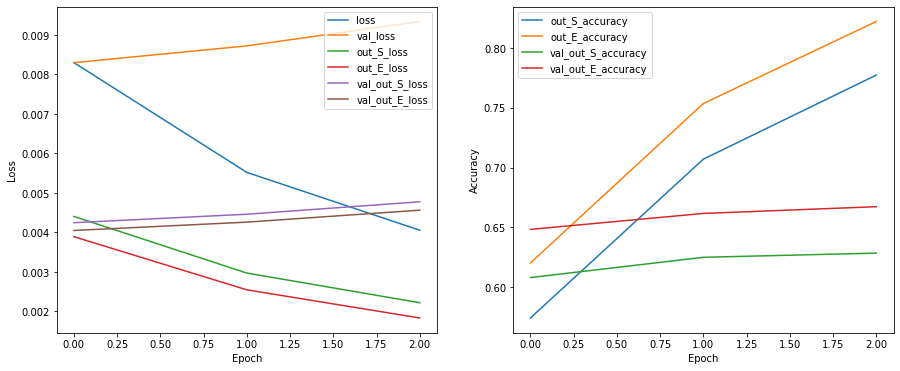

In [15]:
if normal_training:
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    losses = pd.DataFrame(hist, columns=["loss", "val_loss", "out_S_loss", "out_E_loss", "val_out_S_loss", "val_out_E_loss"])
    ax1.plot(losses)
    ax1.legend(losses.columns)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")

    accs = pd.DataFrame(hist, columns=["out_S_accuracy", "out_E_accuracy", "val_out_S_accuracy", "val_out_E_accuracy"])
    ax2.plot(accs)
    ax2.legend(accs.columns)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")

In [ ]:
tf.keras.backend.clear_session()
gc.collect()

#### Training separate layers

In [ ]:
if train_separate_layers:
    # Training cell example: train layers separately. 
    # The same comments from the normal training apply here, but we additionaly save a list
    # of dictionaries since we want to compare all models.
    histories = []

    EPOCHS = 100
    PATIENCE = 3

    # We start from heavier one: it takes longer to train and also uses more GPU memory, 
    # but it's safer to start with the hardest one
    for hidden_state in range(6, 0, -1): 
        # Create checkpoint folder
        checkpoint_dir = os.path.join(config.ROOT_PATH, "data", "training", 
            "training_separate", "layer_" + str(hidden_state))
        os.makedirs(checkpoint_dir, exist_ok=True)
        
        if using_TPU:
            with strategy.scope():
                model = config.create_standard_model(hidden_state)
                model.compile(tf.keras.optimizers.Adam(3e-6),
                    # Anything between 2 and `steps_per_epoch` could help here.
                    steps_per_execution = 64,
                    loss={'out_S': 'binary_crossentropy', 'out_E': 'binary_crossentropy'},
                    metrics={'out_S': 'accuracy', 'out_E': 'accuracy'})
                # Freeze the transformer layers
                transformer = model.get_layer(index=2)
                for layer in transformer.layers:
                    layer.trainable = False

            # Workaraound for saving locally when using cloud TPUs
            local_device_option = tf.train.CheckpointOptions(
                experimental_io_device="/job:localhost")
        else: 
            checkpoint_path = os.path.join(checkpoint_dir, "cp-{epoch:04d}.ckpt")
            log_dir = os.path.join(config.ROOT_PATH, "data", "logs", 
                "training_separate", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

            model = config.create_standard_model(hidden_state)
            model.compile(tf.keras.optimizers.Adam(3e-6), 
                loss={'out_S': 'binary_crossentropy', 'out_E': 'binary_crossentropy'},
                metrics={'out_S': 'accuracy', 'out_E': 'accuracy'})
            # Freeze the transformer layers
            transformer = model.get_layer(index=2)
            for layer in transformer.layers:
                layer.trainable = False

            # ModelCheckpoint callback is only available when not using TPU
            cp_callback = tf.keras.callbacks.ModelCheckpoint(
                filepath = checkpoint_path,
                verbose=1,
                save_weights_only = True,
                save_best_only = False
            )

            tensorboard_callback = tf.keras.callbacks.TensorBoard(
                log_dir=log_dir,
                histogram_freq=1
            )

        es_callback = tf.keras.callbacks.EarlyStopping(
            patience = PATIENCE, restore_best_weights=True
        )

        callbacks = [es_callback]
        if not using_TPU:
            # These callback imply saving stuff on local disk, 
            # which cannot be done automatically using TPUs.
            # Therefore, they are only active when using GPUs
            callbacks.append(cp_callback, tensorboard_callback)

        if using_TPU:
        # Save last weights
            model.save_weights(os.path.join(
                checkpoint_dir, 'tpu_epoch_0.h5'), overwrite=True)
        else:
            model.save_weights(checkpoint_path.format(epoch=0))

        print("\n----------- Training model with head attached to layer number " + str(hidden_state)+ " -----------")

        history = model.fit(
            train_ds, 
            validation_data=val_ds,
            epochs=EPOCHS, 
            callbacks=callbacks
        )

        if using_TPU:
            # Save last weights
            model.save_weights(os.path.join(
                checkpoint_dir, 'tpu_epoch_last.h5'), overwrite=True)
        
        hist = history.history

        if not os.path.exists(os.path.join(checkpoint_dir, "history.json")) or OVERWRITE_HISTORIES:
            # Save history if not there already
            with open(os.path.join(checkpoint_dir, "history.json"), "w") as f:
                json.dump(hist, f)

        histories.append(hist)


In [ ]:
if train_separate_layers:
    # final plot
    for history in histories:
        x = [i for i in range(1,len(history['val_loss'])+1)]
        plt.plot(x, history['val_loss'])

    plt.xlabel("epoch")
    plt.ylabel("val_loss")
    plt.legend(["layer_" + str(i) for i in range(6, 0, -1)])
    plt.show()

#### Training with NER attention enhancement

We implement an alternative layer for attention, where we can load a `NER_attention` vector to use during the batch computation.

In [ ]:
### METHOD ###
sweep_config = {
    'method': 'bayes'
    # 'method': 'grid'
    # 'method': 'random'
}

### METRIC ###
# for remembering
metric = { 
    'name': 'loss',
    'goal': 'minimize'
}
sweep_config["metric"] = metric

### PARAMETERS ###
# discrete hyperparameters
parameters_dict = {
    'optimizer': {
        'values': ['adam', 'sgd']
    },
    'fc_layer_size': {
        'values': [128, 256, 512]
    },
    'dropout': {
        'values': [0.3, 0.4, 0.5]
    }
}
sweep_config["parameters"] = parameters_dict
# fixed hyperparameters
parameters_dict.update({
    'epochs':{
        'value': 100 # valuE not valuES
    }
})
parameters_dict.update({
    'learning_rate':{
        'distribution':'uniform'
    }
})


In [ ]:
sweep_id = wandb.sweep(sweep_config)
wandb.agent(sweep_id, function=NER_training_function)

In [ ]:
bool_q = False
bool_k = False
bool_v = False
NER_value = 0.05

from transformers.models.distilbert.modeling_tf_distilbert import TFMultiHeadSelfAttention as MHSA

class TFInjectMultiHeadSelfAttention(MHSA):

    def __init__(self, config, **kwargs):
        super().__init__(config, **kwargs)


    def load_NER_attention(self, NER_attention):
        self.NER_attention = tf.math.add(tf.math.scalar_mul(NER_value, NER_attention), 1)
        # NE: 1+NER_value
        # nonNE: 1 (so to be more similar to the standard weights)

    def call(self, query, key, value, mask, head_mask, output_attentions, training=False):
        if bool_q: query = query * tf.expand_dims(self.NER_attention, axis=-1)
        if bool_k: key = key * tf.expand_dims(self.NER_attention, axis=-1)
        if bool_v: value = value * tf.expand_dims(self.NER_attention, axis=-1)
        return super().call(query, key, value, mask, head_mask, output_attentions, training=training)

In order to use the loading function, we subclass the `Model` class so that we can define a more complex logic into the `call` function.

In [ ]:
if NER_training:
    CHOSEN_ENHANCED_LAYER = 0
    CHOSEN_OUTPUT_STATES_IDX = [3, 4, 5, 6]
    from transformers import TFDistilBertModel

    class QuestionAnsweringModel(keras.Model):

        def __init__(self, transformer_model: TFDistilBertModel) -> None:
            super(QuestionAnsweringModel, self).__init__()

            global PRETRAINED_WEIGHTS

            self.transformer_model = transformer_model
            # Apply layer change to first attention block
            
            PRETRAINED_WEIGHTS = self.transformer_model.layers[0].transformer.layer[CHOSEN_ENHANCED_LAYER].attention.weights
            # print(weights[0])

            self.transformer_model.layers[0].transformer.layer[CHOSEN_ENHANCED_LAYER].attention = \
                TFInjectMultiHeadSelfAttention(self.transformer_model.config)
                # TFInjectMultiHeadSelfAttention(self.transformer_model.config, weights)
                
            
            # self.transformer_model.layers[0].transformer.layer[CHOSEN_ENHANCED_LAYER].attention.set_weights(weights)
            # weights = self.transformer_model.layers[0].transformer.layer[CHOSEN_ENHANCED_LAYER].attention.get_weights()
            # print(weights[0])

            # Add all remaining layers
            self.dense_S = layers.Dense(1)
            self.dense_E = layers.Dense(1)
            self.flatten = layers.Flatten()
            self.softmax_S = layers.Softmax(name='out_S', dtype='float32')
            self.softmax_E = layers.Softmax(name='out_E', dtype='float32')

        def call(self, inputs, training=False):
            input_ids = inputs["input_ids"]
            attention_mask = inputs["attention_mask"]
            NER_attention = inputs["NER_attention"]

            # Load the NER tensor into the custom layer
            self.transformer_model.layers[0].transformer.layer[CHOSEN_ENHANCED_LAYER].attention.load_NER_attention(NER_attention)

            out = self.transformer_model(
                {
                    "input_ids": input_ids,
                    "attention_mask": attention_mask,
                }
            )

            hidden_states = out.hidden_states
            chosen_states_idx = CHOSEN_OUTPUT_STATES_IDX

            chosen_hidden_states = layers.concatenate(
                tuple([hidden_states[i] for i in chosen_states_idx])
            )
            # chosen_hidden_states = tf.concat([hidden_states[i] for i in chosen_states_idx], axis=2)

            out_S = self.dense_S(chosen_hidden_states) # dot product between token representation and start vector
            out_S = self.flatten(out_S)
            out_S = self.softmax_S(out_S)

            out_E = self.dense_E(chosen_hidden_states) # dot product between token representation and end vector
            out_E = self.flatten(out_E)
            out_E = self.softmax_E(out_E)

            return {'out_S': out_S, 'out_E': out_E}

In [ ]:
if NER_training:
    EPOCHS = 100
    PATIENCE = 2
    LR = 5e-6
    TITLE = "training_NER_FFF"
    # Create the folder where we'll save the weights of the model
    checkpoint_dir = os.path.join(config.ROOT_PATH, "data", "training", TITLE)
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    if using_TPU:
        # TPU requires to create the model within the scope of the distributed strategy
        # we're using.
        with strategy.scope():
            model = QuestionAnsweringModel(config.get_new_distilbert_transformer())
            model.compile(tf.keras.optimizers.Adam(LR),
                # Anything between 2 and `steps_per_epoch` helps, the bigger the better
                # In case of batch 32 and full dataset, the total steps are 1017, so a value of 512
                # implies a communication between tpu and local of only 2/3 times, almost nothing
                steps_per_execution = 512,
                loss={'out_S': 'binary_crossentropy', 'out_E': 'binary_crossentropy'},
                metrics={'out_S': 'accuracy', 'out_E': 'accuracy'})

        # Workaraound for saving locally when using cloud TPUs
        local_device_option = tf.train.CheckpointOptions(
            experimental_io_device="/job:localhost")

    else:
        # GPUs and local systems don't need the above specifications. We simply
        # create a pattern for the filename and let the callbacks deal with it.
        checkpoint_path = os.path.join(checkpoint_dir, "cp-{epoch:04d}.ckpt")
        # Also, on TPU we cannot use tensorboard
        log_dir = os.path.join(checkpoint_dir, datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
        
        model = QuestionAnsweringModel(config.get_new_distilbert_transformer())

        _ = model(DUMMY_SAMPLE[0]) ### IMPORTANT! otherwise it wouldn't be possible to recover pretrained weights

        # weights = model.transformer_model.layers[0].transformer.layer[CHOSEN_ENHANCED_LAYER].attention.weights
        # model.transformer_model.layers[0].transformer.layer[CHOSEN_ENHANCED_LAYER].attention.set_weights(weights)
        model.compile(tf.keras.optimizers.Adam(LR), 
            loss={'out_S': 'binary_crossentropy', 'out_E': 'binary_crossentropy'},
            metrics={'out_S': 'accuracy', 'out_E': 'accuracy'})

        # print(PRETRAINED_WEIGHTS[0])
        model.transformer_model.layers[0].transformer.layer[CHOSEN_ENHANCED_LAYER].attention.set_weights(PRETRAINED_WEIGHTS)

        # ModelCheckpoint callback is only available when not using TPU
        cp_callback = tf.keras.callbacks.ModelCheckpoint(
            filepath = checkpoint_path,
            verbose=1,
            save_weights_only = True,
            save_best_only = False
        )
        # Same for tensorboard callback
        tensorboard_callback = tf.keras.callbacks.TensorBoard(
            log_dir=log_dir,
            histogram_freq=1
        )

    # Early stopping can be used by both hardware
    es_callback = tf.keras.callbacks.EarlyStopping(
        patience = PATIENCE,
        restore_best_weights=True
    )
    
    if using_TPU:
        # Save first weights in a h5 file (it's the most stable way)
        model.save_weights(os.path.join(
            checkpoint_dir, TITLE+'_tpu_0.h5'),  overwrite=True)
    else:
        # Save the first weights using the pattern from before
        model.save_weights(checkpoint_path.format(epoch=0))

    callbacks = [es_callback]
    if not using_TPU:
        # These callback imply saving stuff on local disk, which cannot be 
        # done automatically using TPUs.
        # Therefore, they are only active when using GPUs and local systems
        callbacks.append(tensorboard_callback)
        # callbacks.append(cp_callback)

    # We fit the model
    history = model.fit(
        train_ds, 
        validation_data=val_ds,
        epochs=EPOCHS, 
        callbacks=callbacks,
        use_multiprocessing = True,
        initial_epoch=0
    )

    if using_TPU:
        # Save last weights
        model.save_weights(os.path.join( 
            checkpoint_dir, TITLE+'_tpu_last.h5'), overwrite=True)

In [ ]:
hist = history.history
if not os.path.exists(os.path.join(checkpoint_dir, "history.json")) or OVERWRITE_HISTORIES:
    # Save history if not there already
    with open(os.path.join(checkpoint_dir, "history.json"), "w") as f:
        json.dump(hist, f)

In [ ]:
NER_training_loop = True
bool_q = False
bool_k = False
bool_v = False

from transformers.models.distilbert.modeling_tf_distilbert import TFMultiHeadSelfAttention as MHSA

def training_NER(NER_value):

    CHOSEN_ENHANCED_LAYER = 0
    CHOSEN_OUTPUT_STATES_IDX = [3, 4, 5, 6]
    EPOCHS = 100
    PATIENCE = 2
    LR = 5e-6
    TITLE = "training_NER_FFF"

    class TFInjectMultiHeadSelfAttention(MHSA):

        def __init__(self, config, **kwargs):
            super().__init__(config, **kwargs)

        def load_NER_attention(self, NER_attention):
            self.NER_attention = tf.math.add(tf.math.scalar_mul(NER_value, NER_attention), 1)
            # NE: 1+NER_value
            # nonNE: 1 (so to be more similar to the standard weights)

        def call(self, query, key, value, mask, head_mask, output_attentions, training=False):
            if bool_q: query = query * tf.expand_dims(self.NER_attention, axis=-1)
            if bool_k: key = key * tf.expand_dims(self.NER_attention, axis=-1)
            if bool_v: value = value * tf.expand_dims(self.NER_attention, axis=-1)
            return super().call(query, key, value, mask, head_mask, output_attentions, training=training)


    
    from transformers import TFDistilBertModel

    class QuestionAnsweringModel(keras.Model):

        def __init__(self, transformer_model: TFDistilBertModel) -> None:
            super(QuestionAnsweringModel, self).__init__()

            global PRETRAINED_WEIGHTS

            self.transformer_model = transformer_model
            # Apply layer change to first attention block
            
            PRETRAINED_WEIGHTS = self.transformer_model.layers[0].transformer.layer[CHOSEN_ENHANCED_LAYER].attention.weights

            self.transformer_model.layers[0].transformer.layer[CHOSEN_ENHANCED_LAYER].attention = \
                TFInjectMultiHeadSelfAttention(self.transformer_model.config)

            # Add all remaining layers
            self.dense_S = layers.Dense(1)
            self.dense_E = layers.Dense(1)
            self.flatten = layers.Flatten()
            self.softmax_S = layers.Softmax(name='out_S', dtype='float32')
            self.softmax_E = layers.Softmax(name='out_E', dtype='float32')

        def call(self, inputs, training=False):
            input_ids = inputs["input_ids"]
            attention_mask = inputs["attention_mask"]
            NER_attention = inputs["NER_attention"]

            # Load the NER tensor into the custom layer
            self.transformer_model.layers[0].transformer.layer[CHOSEN_ENHANCED_LAYER].attention.load_NER_attention(NER_attention)

            out = self.transformer_model(
                {
                    "input_ids": input_ids,
                    "attention_mask": attention_mask,
                }
            )

            hidden_states = out.hidden_states
            chosen_states_idx = CHOSEN_OUTPUT_STATES_IDX

            chosen_hidden_states = layers.concatenate(
                tuple([hidden_states[i] for i in chosen_states_idx])
            )
            # chosen_hidden_states = tf.concat([hidden_states[i] for i in chosen_states_idx], axis=2)

            out_S = self.dense_S(chosen_hidden_states) # dot product between token representation and start vector
            out_S = self.flatten(out_S)
            out_S = self.softmax_S(out_S)

            out_E = self.dense_E(chosen_hidden_states) # dot product between token representation and end vector
            out_E = self.flatten(out_E)
            out_E = self.softmax_E(out_E)

            return {'out_S': out_S, 'out_E': out_E}

    

    # Create the folder where we'll save the weights of the model
    checkpoint_dir = os.path.join(config.ROOT_PATH, "data", "training", TITLE)
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    if using_TPU:
        # TPU requires to create the model within the scope of the distributed strategy
        # we're using.
        with strategy.scope():
            model = QuestionAnsweringModel(config.get_new_distilbert_transformer())
            model.compile(tf.keras.optimizers.Adam(LR),
                # Anything between 2 and `steps_per_epoch` helps, the bigger the better
                # In case of batch 32 and full dataset, the total steps are 1017, so a value of 512
                # implies a communication between tpu and local of only 2/3 times, almost nothing
                steps_per_execution = 512,
                loss={'out_S': 'binary_crossentropy', 'out_E': 'binary_crossentropy'},
                metrics={'out_S': 'accuracy', 'out_E': 'accuracy'})

        # Workaraound for saving locally when using cloud TPUs
        local_device_option = tf.train.CheckpointOptions(
            experimental_io_device="/job:localhost")

    else:
        # GPUs and local systems don't need the above specifications. We simply
        # create a pattern for the filename and let the callbacks deal with it.
        checkpoint_path = os.path.join(checkpoint_dir, "cp-{epoch:04d}.ckpt")
        # Also, on TPU we cannot use tensorboard
        log_dir = os.path.join(checkpoint_dir, datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
        
        model = QuestionAnsweringModel(config.get_new_distilbert_transformer())

        _ = model(DUMMY_SAMPLE[0]) ### IMPORTANT! otherwise it wouldn't be possible to recover pretrained weights

        # weights = model.transformer_model.layers[0].transformer.layer[CHOSEN_ENHANCED_LAYER].attention.weights
        # model.transformer_model.layers[0].transformer.layer[CHOSEN_ENHANCED_LAYER].attention.set_weights(weights)
        model.compile(tf.keras.optimizers.Adam(LR), 
            loss={'out_S': 'binary_crossentropy', 'out_E': 'binary_crossentropy'},
            metrics={'out_S': 'accuracy', 'out_E': 'accuracy'})

        # print(PRETRAINED_WEIGHTS[0])
        model.transformer_model.layers[0].transformer.layer[CHOSEN_ENHANCED_LAYER].attention.set_weights(PRETRAINED_WEIGHTS)

        # ModelCheckpoint callback is only available when not using TPU
        cp_callback = tf.keras.callbacks.ModelCheckpoint(
            filepath = checkpoint_path,
            verbose=1,
            save_weights_only = True,
            save_best_only = False
        )
        # Same for tensorboard callback
        tensorboard_callback = tf.keras.callbacks.TensorBoard(
            log_dir=log_dir,
            histogram_freq=1
        )

    # Early stopping can be used by both hardware
    es_callback = tf.keras.callbacks.EarlyStopping(
        patience = PATIENCE,
        restore_best_weights=True
    )
    
    if using_TPU:
        # Save first weights in a h5 file (it's the most stable way)
        model.save_weights(os.path.join(
            checkpoint_dir, TITLE+'_tpu_0.h5'),  overwrite=True)
    else:
        # Save the first weights using the pattern from before
        model.save_weights(checkpoint_path.format(epoch=0))

    callbacks = [es_callback]
    if not using_TPU:
        # These callback imply saving stuff on local disk, which cannot be 
        # done automatically using TPUs.
        # Therefore, they are only active when using GPUs and local systems
        callbacks.append(tensorboard_callback)
        # callbacks.append(cp_callback)

    # We fit the model
    history = model.fit(
        train_ds, 
        validation_data=val_ds,
        epochs=EPOCHS, 
        callbacks=callbacks,
        use_multiprocessing = True,
        initial_epoch=0
    )

    if using_TPU:
        # Save last weights
        model.save_weights(os.path.join( 
            checkpoint_dir, TITLE+'_tpu_last.h5'), overwrite=True)